# Métricas do modelo EfficientNetV2S para o Plantvillage

Abrindo dataset

In [1]:
import pandas as pd

df = pd.read_csv('Dataset/processed/plantvillage_data.csv')
df

,Unnamed: 0,file_path,version,class,plant,disease
0,0,Dataset/plantvillage_dataset/segmented/Apple__...,segmented,Apple___Apple_scab,Apple,Apple_scab
1,1,Dataset/plantvillage_dataset/segmented/Apple__...,segmented,Apple___Apple_scab,Apple,Apple_scab
2,2,Dataset/plantvillage_dataset/segmented/Apple__...,segmented,Apple___Apple_scab,Apple,Apple_scab
3,3,Dataset/plantvillage_dataset/segmented/Apple__...,segmented,Apple___Apple_scab,Apple,Apple_scab
4,4,Dataset/plantvillage_dataset/segmented/Apple__...,segmented,Apple___Apple_scab,Apple,Apple_scab
...,...,...,...,...,...,...
162911,162911,Dataset/plantvillage_dataset/color/Tomato___he...,color,Tomato___healthy,Tomato,healthy
162912,162912,Dataset/plantvillage_dataset/color/Tomato___he...,color,Tomato___healthy,Tomato,healthy
162913,162913,Dataset/plantvillage_dataset/color/Tomato___he...,color,Tomato___healthy,Tomato,healthy
162914,162914,Dataset/plantvillage_dataset/color/Tomato___he...,color,Tomato___healthy,Tomato,healthy


Extraíndo caminhos das imagens e rótulos

In [2]:
caminhos_imagens = df['file_path'].values
rotulos = df['class'].values

Importando label enconder

In [3]:
import joblib

label_encoder = joblib.load('labelencoder_efficientnetv2s_plantvillage.pkl')
label_encoder

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](38,)","['Apple___Apple_scab','Apple___Black_rot','Apple___Cedar_apple_rust',..., 'Tomato___Tomato_Yellow_Leaf_Curl_Virus','Tomato___Tomato_mosaic_virus', 'Tomato___healthy']"


Convertendo rótulos de texto para número

In [4]:
rotulos_inteiros = label_encoder.transform(rotulos)
num_classes = len(label_encoder.classes_)
print(rotulos_inteiros)
print(num_classes)

[ 0  0  0 ... 37 37 37]
38


Dividindo em conjunto de treino e conjunto de teste

In [5]:
from sklearn.model_selection import train_test_split

x_treino, x_val, y_treino, y_val = train_test_split(
    caminhos_imagens,
    rotulos_inteiros,
    test_size=0.2,
    random_state=1024,
    stratify=rotulos_inteiros
)

Definindo constantes

In [6]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

I0000 00:00:1783356648.811515   45450 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783356648.812061   45450 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783356648.835486   45450 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783356649.492460   45450 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

Definindo função para pré-processamento das imagens

In [7]:
import tensorflow as tf

def preprocessar_imagem_efficientnetv2s(caminho, rotulo):
    # Lendo imagem do disco
    img = tf.io.read_file(caminho)

    # Decodificando o JPEG (assume que seja .jpg)
    img = tf.image.decode_jpeg(img, channels=3)

    # Redimensionando imagem para o 224x224
    img = tf.image.resize(img, IMG_SIZE)

    # Convertendo os pixels para o tipo float32
    img = tf.cast(img, tf.float32)

    # Aplica o pré-processamento específico da EfficientNetV2S
    img = tf.keras.applications.efficientnet_v2.preprocess_input(img)

    return img, rotulo

Criando dataset do tensorflow

In [8]:
ds_val = tf.data.Dataset.from_tensor_slices((x_val, y_val))
ds_val = ds_val.map(preprocessar_imagem_efficientnetv2s, num_parallel_calls=AUTOTUNE)
ds_val = ds_val.batch(BATCH_SIZE).prefetch(AUTOTUNE)

E0000 00:00:1783356680.336747   45450 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1783356680.337130   46898 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1783356680.363668   45450 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Importando modelo

In [9]:
model = tf.keras.models.load_model('modelo_efficientnetv2s_plantvillage.keras')
model

<Sequential name=sequential, built=True>

Obtendo métricas

In [10]:
predicoes = model.predict(ds_val)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 381s 373ms/step


Gerando matriz de confusão

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Convertendo as probabilidades em classes (índices inteiros)
y_pred = np.argmax(predicoes, axis=1)

# Extraíndo os rótulos reais (y_true) do dataset de validação
# Precisamos disso porque o ds_val retorna a imagem e uma tupla de 3 rótulos (devido aos 3 outputs)
y_true = []
for imagens, rotulo in ds_val.unbatch():
    # Pegamos apenas o primeiro rótulo da tupla, que corresponde ao main_output
    y_true.append(rotulo.numpy())
y_true = np.array(y_true)

# Gerando matriz de confusão
matriz_confusao = confusion_matrix(y_true, y_pred)


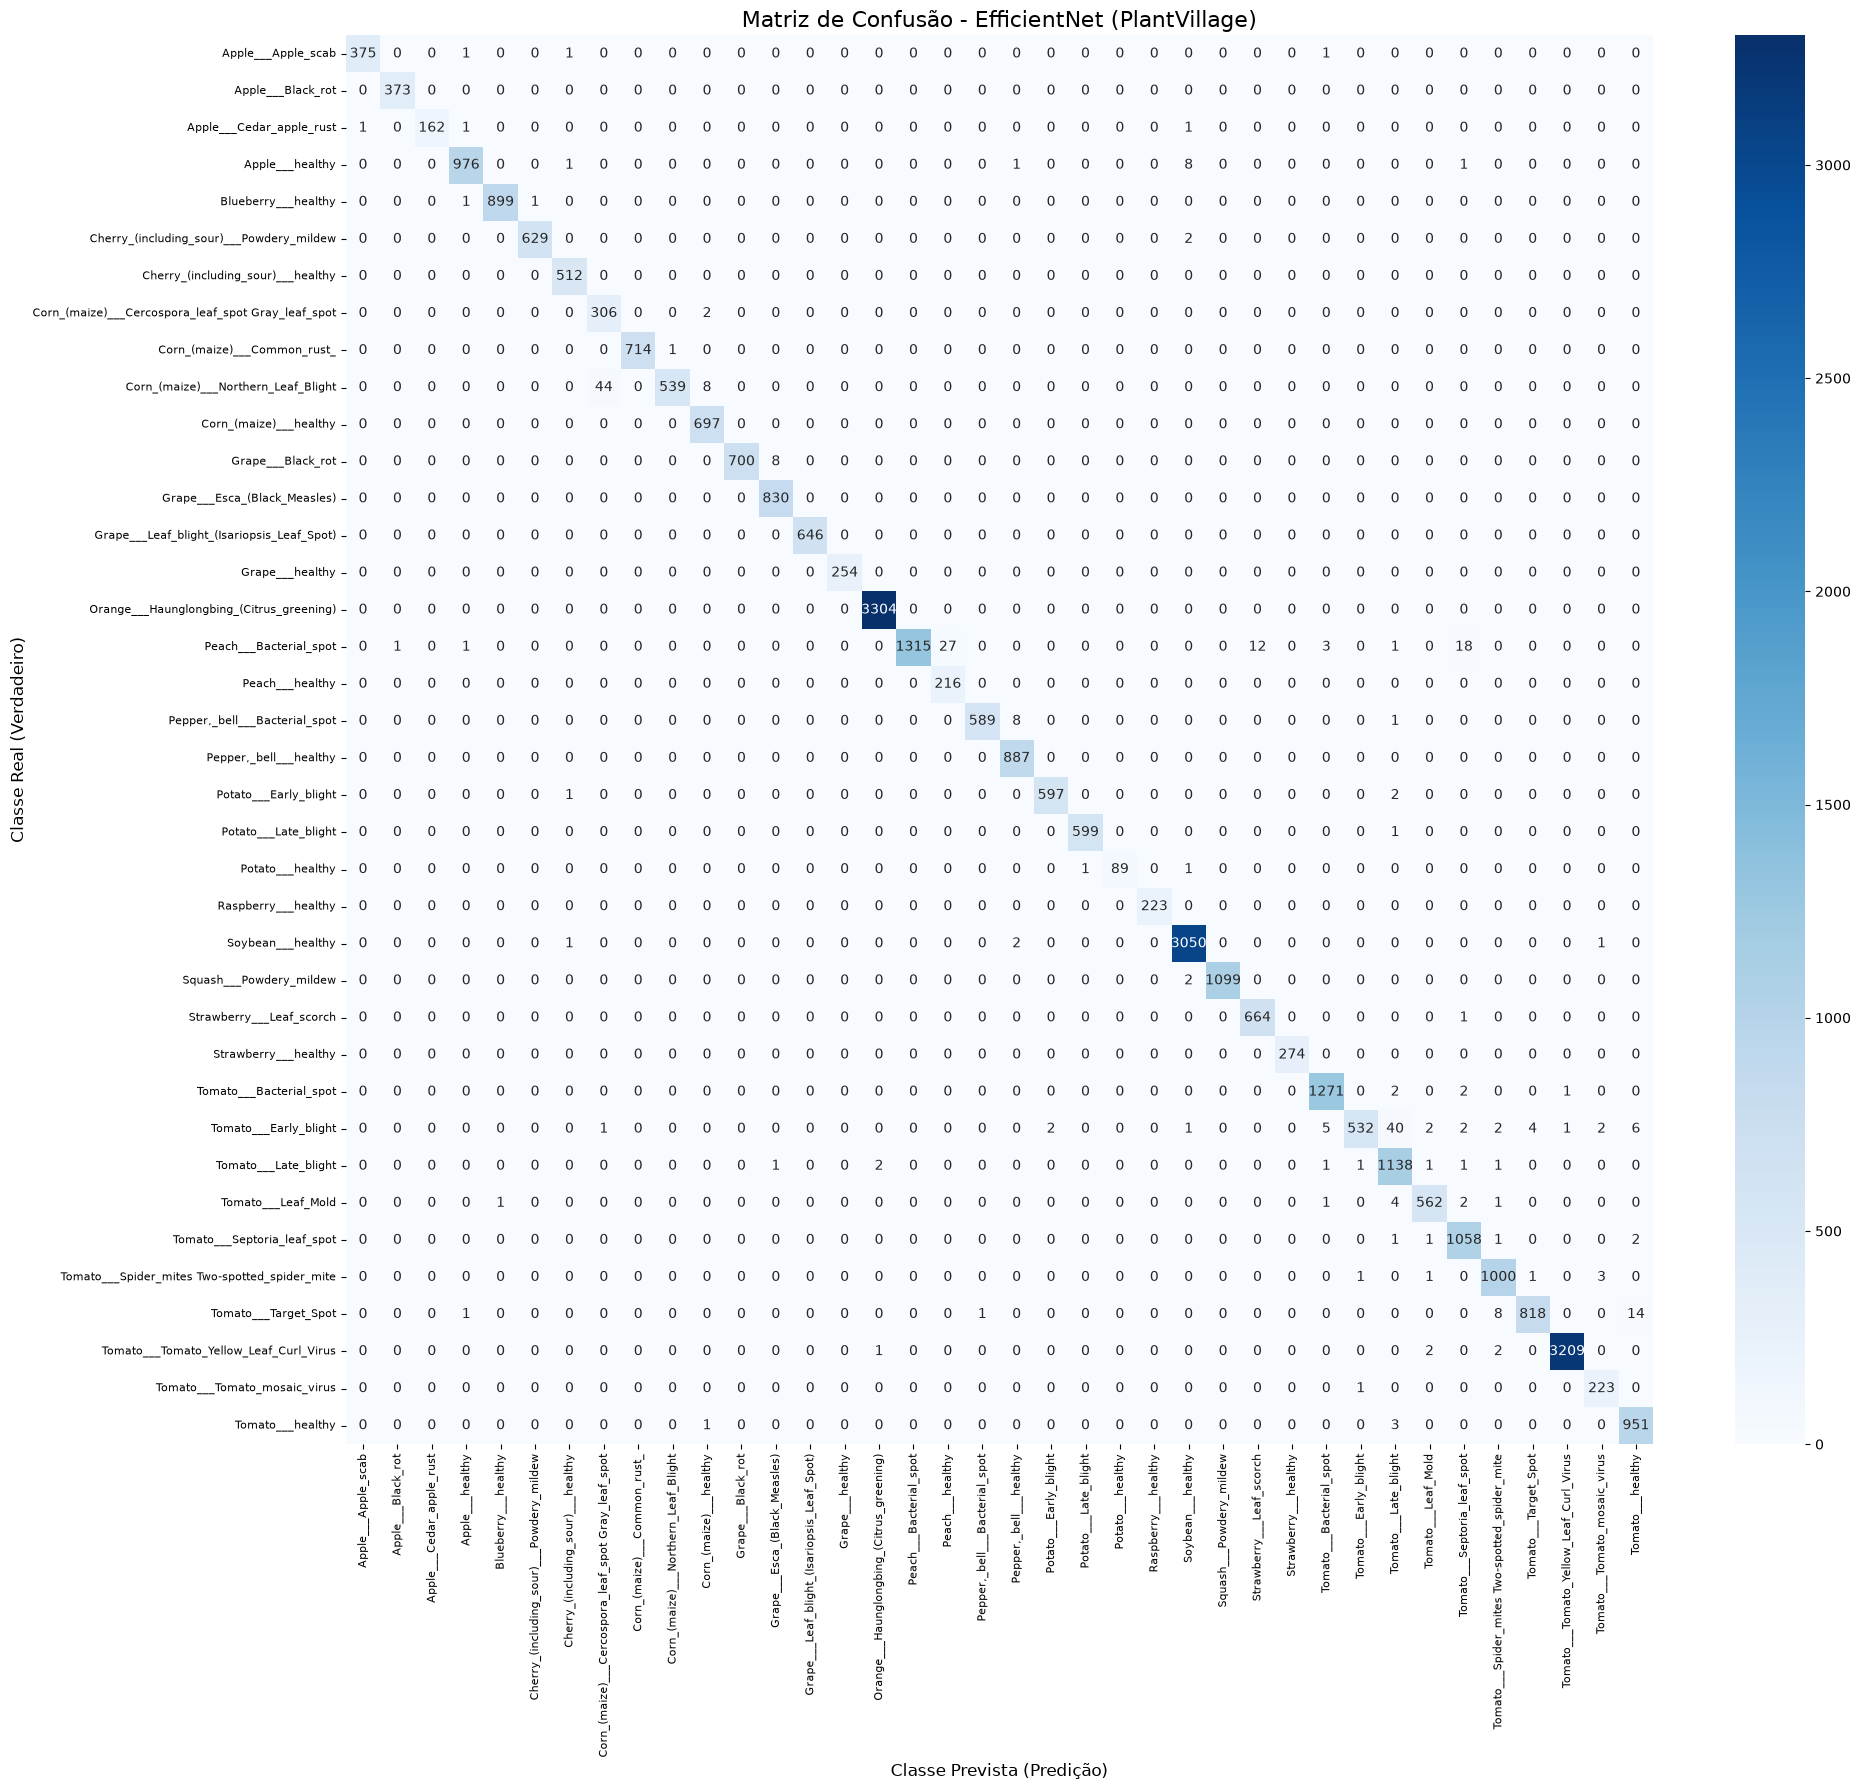

Matriz de confusão gerada e salva com sucesso!


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotando a Matriz de Confusão de forma visual
plt.figure(figsize=(20, 18))

# Gerando o heatmap
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

# Ajustes visuais para não sobrepor os textos
plt.xticks(rotation=90, fontsize=8) # Rotação e tamanho da fonte do eixo X
plt.yticks(rotation=0, fontsize=8) # Tamanho da fonte do eixo Y

plt.xlabel('Classe Prevista (Predição)', fontsize=12)
plt.ylabel('Classe Real (Verdadeiro)', fontsize=12)
plt.title('Matriz de Confusão - EfficientNet (PlantVillage)', fontsize=16)

# Ajusta o layout para não cortar os rótulos
plt.tight_layout()

# Salva a imagem em alta resolução
plt.savefig('matriz_confusao_efficientnet_plantvillage.png', dpi=300)

# Mostra na tela
plt.show()

print('Matriz de confusão gerada e salva com sucesso!')

Plotando gráfico relacionado ao histórico de treinamento

In [13]:
import json

with open ('historico_treinamento_efficientnet_plantvillage.json', 'r') as file:
    historico_treinamento = json.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'historico_treinamento_efficientnet_plantvillage.json'

In [14]:
import matplotlib.pyplot as plt

# Acessando os dados do histórico
acuracia_treino = historico_treinamento['main_output_accuracy']
acuracia_validacao = historico_treinamento['val_main_output_accuracy']

# Criando uma lista com o número de épocas
epocas = range(1, len(acuracia_treino) + 1)

# Criando gráfico
plt.figure(figsize=(10, 6))

# Plotando a linha do treino (azul)
plt.plot(epocas, acuracia_treino, 'b-o', label='Treino (main_output)', markersize=5)

# Plotando a linha da validação (laranja/vermelha)
plt.plot(epocas, acuracia_validacao, 'r-o', label='Validação (main_output)', markersize=5)

# Personalizando o gráfico
plt.title('Histórico de Acurácia por Época - EfficientNet', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Definindo os limites do eixo Y entre 0 e 1 (ou 0% e 100%) para melhor visualização
plt.ylim(0, 1)

# Exibindo o gráfico
plt.show()

NameError: name 'historico_treinamento' is not defined

Gerando métricas

In [15]:
from sklearn.metrics import multilabel_confusion_matrix

def gerar_metricas(y_pred, y_true):
    matrizes_de_confusao = multilabel_confusion_matrix(y_pred=y_pred, y_true=y_true)
    resultado = []
    for i in range(len(matrizes_de_confusao)):
        vn, fp, fn, vp = matrizes_de_confusao[i].ravel()
        tvp = vp / (vp + fn)
        tvn = vn / (vn + fp)
        tfp = fp / (fp + vn)
        tfn = fn / (fn + vp)
        resultado.append({
            'tvp': tvp,
            'tvn': tvn,
            'tfp': tfp,
            'tfn': tfn
        })

    return resultado

In [16]:
import numpy as np

def gerar_metricas_media(y_pred, y_true):
    metricas = gerar_metricas(y_pred=y_pred, y_true=y_true)
    tvp_medio = np.average([i['tvp'] for i in metricas])
    tvn_medio = np.average([i['tvn'] for i in metricas])
    tfp_medio = np.average([i['tfp'] for i in metricas])
    tfn_medio = np.average([i['tfn'] for i in metricas])
    return {
        'tvp_medio': tvp_medio,
        'tvn_medio': tvn_medio,
        'tfp_medio': tfp_medio,
        'tfn_medio': tfn_medio
    }

In [17]:
gerar_metricas_media(y_pred=y_pred, y_true=y_true)

{'tvp_medio': np.float64(0.9885987305127136),
 'tvn_medio': np.float64(0.9997472136956506),
 'tfp_medio': np.float64(0.0002527863043493335),
 'tfn_medio': np.float64(0.011401269487286432)}

Obtendo acurácia e perda

In [18]:
from sklearn.metrics import accuracy_score, log_loss

acuracia = accuracy_score(y_true=y_true, y_pred=y_pred)
perda = log_loss(y_true=y_true, y_pred=predicoes)

print(f'Acurácia: {acuracia}')
print(f'Perda: {perda}')

Acurácia: 0.9906702676160078
Perda: 0.02663467451930046


/home/henrique/Dev/Repositorios_Git/Em_desenvolvimento/GitHub.com/Henriquemcc/Mestrado em Informatica/Projeto_Final_-_Topicos_em_AD2I-2026-1/.venv/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(
